Data loaded successfully! Dataset Shape: (4521, 17)

================ MODEL EVALUATION ================
Accuracy Score: 90.17%

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.97      0.95       807
           1       0.58      0.32      0.41        98

    accuracy                           0.90       905
   macro avg       0.75      0.64      0.68       905
weighted avg       0.88      0.90      0.89       905




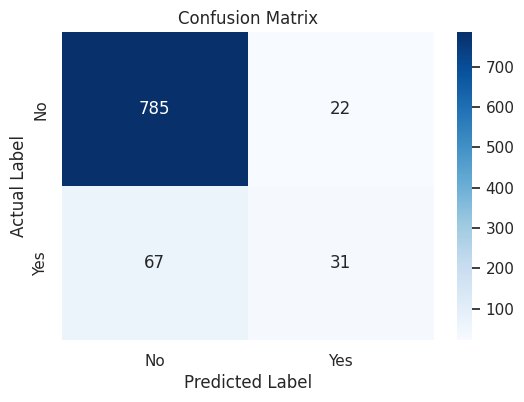

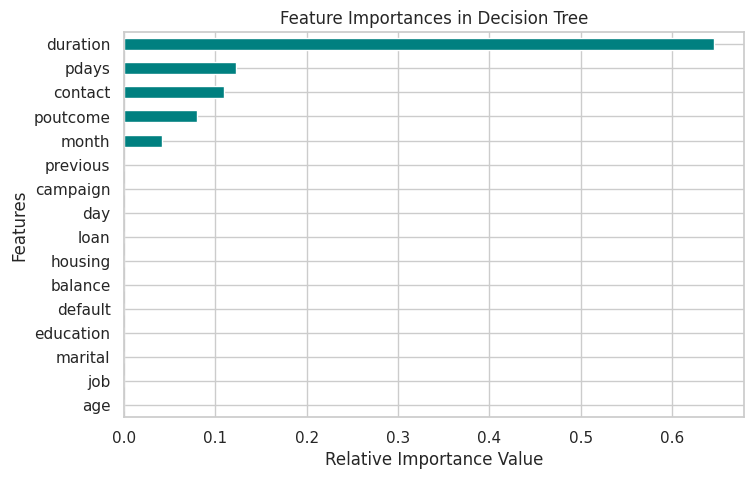

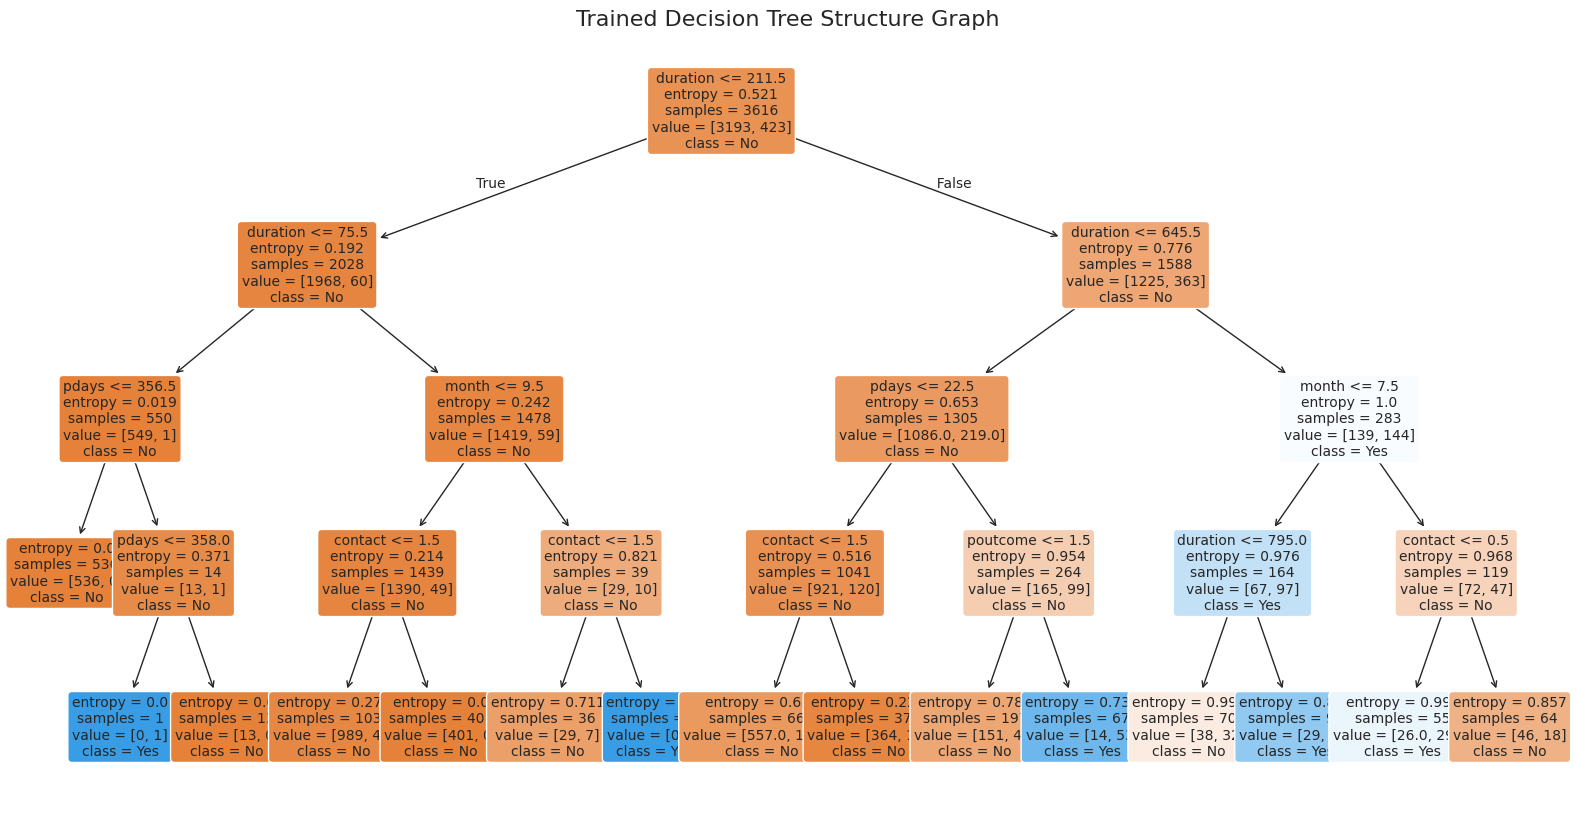

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import requests
import zipfile
import io
import urllib3

# --- STEP 1: Download and Extract the Dataset (with SSL Fix) ---
print("Downloading Bank Marketing Dataset...")
url = "https://archive.ics.uci.edu/static/public/222/bank+marketing.zip"

# Suppress the insecure request warnings in the console output
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# Bypass the expired SSL certificate validation using verify=False
response = requests.get(url, verify=False)
zip_file = zipfile.ZipFile(io.BytesIO(response.content))

# Extract the inner bank.zip file containing the data
inner_zip_data = zip_file.read('bank.zip')
inner_zip = zipfile.ZipFile(io.BytesIO(inner_zip_data))

# Load bank.csv using a semicolon delimiter
df = pd.read_csv(inner_zip.open('bank.csv'), sep=';')
print("Data loaded successfully! Dataset Shape:", df.shape)

# --- STEP 2: Preprocessing & Feature Encoding ---
# Identify non-numeric columns that need encoding
categorical_cols = df.select_dtypes(include=['object']).columns

# Convert textual categories into numeric integers
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Split data into Features (X) and Target (y - 'y' column indicates purchase outcome)
X = df.drop(columns=['y'])
y = df['y']

# Perform an 80/20 Train-Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- STEP 3: Train the Decision Tree Classifier ---
# Restricting max_depth to 4 to prevent overfitting and ensure the visual tree is legible
clf = DecisionTreeClassifier(max_depth=4, random_state=42, criterion='entropy')
clf.fit(X_train, y_train)

# --- STEP 4: Evaluate the Model Metrics ---
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("\n================ MODEL EVALUATION ================")
print(f"Accuracy Score: {accuracy:.2%}\n")
print("Classification Report:\n", classification_report(y_test, y_pred))
print("==================================================\n")

# --- STEP 5: Visualizations ---
# Set the default seaborn theme for clean graphics
sns.set_theme(style="whitegrid")

# 1. Plot the Confusion Matrix
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

# 2. Plot Feature Importance Rankings
importances = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=True)
plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='teal')
plt.title('Feature Importances in Decision Tree')
plt.xlabel('Relative Importance Value')
plt.ylabel('Features')
plt.show()

# 3. Plot the Tree Diagram
plt.figure(figsize=(20, 10))
plot_tree(clf, feature_names=X.columns, class_names=['No', 'Yes'], filled=True, rounded=True, fontsize=10)
plt.title('Trained Decision Tree Structure Graph', fontsize=16)
plt.show()